In [334]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from scipy.signal import savgol_filter

In [335]:
lengths = {
    'AB': 2.0,
    'AD': 2.0,
    'AC': 2.0,
    'AE': 2.0,
    'EG': 1.0,
    'CG': 1.0,
    'BF': 1.0,
    'DF': 1.0,
    'BH': 4.0,
    'CI': 4.0,
    'DI': 4.0,
    'EH': 4.0,
}
lengths['FH'] = lengths['BH'] - lengths['BF']
scale = 0.1
phi3_init = 0  # initial condition for fsolve
phi4_init = 0.2 
phi1 = 0


t_begin =  0     # start time of simulation
t_end   = 45     # end time of simulation
Ts      =  0.10  # time step of simulation
T = Ts*t_end
t = np.arange(t_begin, t_end + Ts, Ts)  # time vector
rho= 7850 # dichtheid van staal in kg/m^3 
dikte = scale # dikte van de balken in m

masses = { link: lengths[link] * rho * dikte**2 for link in lengths }
I = { link: (1/12) * masses[link] * lengths[link]**2 for link in lengths }
# angular position driver:
omega  = 0.3     # driver frequency [rad/s]
A      = 1.2        # amplitude []
gravity = False
friction = False
spring = False
k_spring = 1.0        # Nm/rad — torsion spring stiffness
phi0_spring = np.radians(20)
g = 9.81  # gravity acceleration [m/s^2]
c = 0.05

F_ext = np.zeros((len(t), 2))  # external force vector (x,y) for each timestep


phi2_min = np.radians(5)    # "almost 0" — stay away from singularity
phi2_max = np.radians(65)   # "fully extended" — stay away from phi=pi too

# Cosine motion law (smooth start/stop, zero velocity at endpoints)
phi2 = phi2_min + 0.5 * (phi2_max - phi2_min) * (1 - np.cos(2 * np.pi * t / T))

# Derivatives (analytical, no numerical noise)
dphi2  =      0.5 * (phi2_max - phi2_min) * (2*np.pi/T) * np.sin(2 * np.pi * t / T)
ddphi2 =      0.5 * (phi2_max - phi2_min) * (2*np.pi/T)**2 * np.cos(2 * np.pi * t / T)
x_zaag = 2 * lengths['AB'] * np.sin(phi2)
F_ext[:, 0] = np.ones(len(t)) * 500
F_ext[:, 1] = np.ones(len(t)) * 0.2 * 500


    
# initial conditions for nonlinear solver ("fsolve") of position closure:
print(np.degrees(phi2))
phi3_init = 1
phi4_init = 2


[ 5.          5.29195794  6.16214912  7.59363627  9.55855712 12.01866671
 14.92608181 18.2242129  21.8488656  25.72949017 29.79055467 33.9530151
 38.1358539  42.25765687 46.2381978  50.         53.46984426 56.58019401
 59.27050983 61.48842779 63.19077862 64.34442802 64.92692151 64.92692151
 64.34442802 63.19077862 61.48842779 59.27050983 56.58019401 53.46984426
 50.         46.2381978  42.25765687 38.1358539  33.9530151  29.79055467
 25.72949017 21.8488656  18.2242129  14.92608181 12.01866671  9.55855712
  7.59363627  6.16214912  5.29195794  5.          5.29195794  6.16214912
  7.59363627  9.55855712 12.01866671 14.92608181 18.2242129  21.8488656
 25.72949017 29.79055467 33.9530151  38.1358539  42.25765687 46.2381978
 50.         53.46984426 56.58019401 59.27050983 61.48842779 63.19077862
 64.34442802 64.92692151 64.92692151 64.34442802 63.19077862 61.48842779
 59.27050983 56.58019401 53.46984426 50.         46.2381978  42.25765687
 38.1358539  33.9530151  29.79055467 25.72949017 21.84

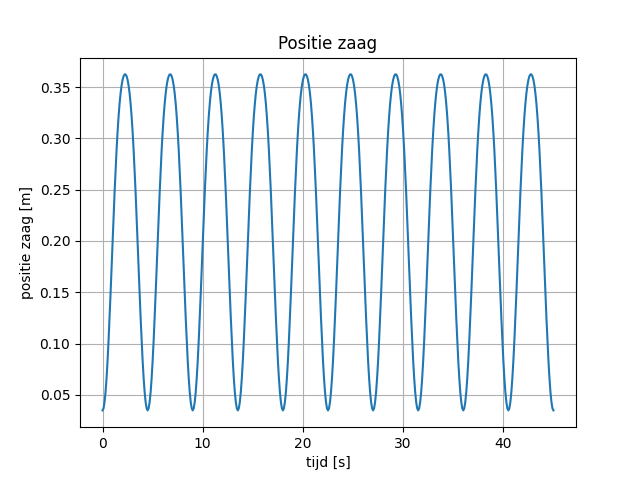

In [336]:
plt.close()
plt.figure()
plt.plot(t, x_zaag*scale)
plt.xlabel('tijd [s]')
plt.ylabel('positie zaag [m]')
plt.title('Positie zaag')
plt.grid(True)
plt.show()

In [337]:
# Function to rotate a vector z over an angle theta:
def rotate_vector(z, theta):
    rotation_matrix = np.array([[np.cos(theta), -np.sin(theta)],
                                [np.sin(theta), np.cos(theta)]])
    return np.dot(rotation_matrix, z)
# Define function to compute "gap" in position closure:
def loop_closure_eqs(phi_init, phi2, r1, r2, r3, r4, phi1):
    phi3 = phi_init[0]
    phi4 = phi_init[1]

    # Loop closure gaps:
    F1 = r1*np.cos(phi1) + r2 * np.cos(phi2) - r3 * np.cos(phi3) - r4 * np.cos(phi4)
    F2 = r1*np.sin(phi1) + r2 * np.sin(phi2) - r3 * np.sin(phi3) - r4 * np.sin(phi4)

    return [F1, F2]
# Function to compute the kinematics of four-bar mechanism:

def kinematics_4bar(r1, r2, r3, r4, phi1, phi2, dphi2, ddphi2, phi3_init, phi4_init, t):
    #global phi3, phi4, dphi3, dphi4, ddphi3, ddphi4, cond
    phi3   = np.zeros_like(t)
    phi4   = np.zeros_like(t)
    dphi3  = np.zeros_like(t)
    dphi4  = np.zeros_like(t)
    ddphi3 = np.zeros_like(t)
    ddphi4 = np.zeros_like(t)
    cond   = np.zeros_like(t)


    optim_options = {"full_output":True}  # options for fsolve


    # numerically solving the position closure at all sampling times:
    for k, time in enumerate(t):
        # Position Analysis
        x, _, ier, message  = fsolve(lambda x: loop_closure_eqs(x, phi2[k], r1, r2, r3, r4, phi1), [phi3_init, phi4_init], **optim_options)

        if ier != 1:
            print(f"k={k}: fsolve did not converge — {message}")

        phi3[k] = (x[0] + np.pi) % (2*np.pi) - np.pi
        phi4[k] = (x[1] + np.pi) % (2*np.pi) - np.pi

        # velocity closure:
        A = np.array([[r3 * np.sin(phi3[k]), r4 * np.sin(phi4[k])],
                        [-r3 * np.cos(phi3[k]), -r4 * np.cos(phi4[k])]]) # jacobiaan, zelfde voor snelheden en versnellingen
        B = np.array([r2 * np.sin(phi2[k]) * dphi2[k],
                        -r2 * np.cos(phi2[k]) * dphi2[k]])

        x = np.linalg.solve(A, B)
        dphi3[k] = x[0]
        dphi4[k] = x[1]
        cond[k]  = np.linalg.cond(A)

        # acceleration closure:
        B = np.array([r2 * np.cos(phi2[k]) * dphi2[k]**2 + r2 * np.sin(phi2[k]) * ddphi2[k] - r3 * np.cos(phi3[k]) * dphi3[k]**2 - r4 * np.cos(phi4[k]) * dphi4[k]**2,
                        r2 * np.sin(phi2[k]) * dphi2[k]**2 - r2 * np.cos(phi2[k]) * ddphi2[k] - r3 * np.sin(phi3[k]) * dphi3[k]**2 - r4 * np.sin(phi4[k]) * dphi4[k]**2])

        # Note: A matrix is the same as for velocities.
        x = np.linalg.solve(A, B)
        ddphi3[k] = x[0]
        ddphi4[k] = x[1]

        # Next iteration with initial values from by simple integration:
        phi3_init = phi3[k] + (t[1] - t[0]) * dphi3[k] * 0.5
        phi4_init = phi4[k] + (t[1] - t[0]) * dphi4[k] * 0.5

    return phi3, phi4, dphi3, dphi4, ddphi3, ddphi4, cond

In [338]:
# Animation of mechanism motion
global fig, ax, x_left, x_right, y_bottom, y_top, B, F, index_vec
# compute width and height of drawing canvas:
x_left   = -0.5*(lengths['AB'])
y_bottom = -1.25 * (lengths['BH'])
x_right  = 2.5 *(lengths['AB'])
y_top    = 1.25 *(lengths['AB'])

plt.close()
# Don't show figure until drawn explicitly:
plt.ioff()
# Initialize the figure
fig, ax = plt.subplots()

# Define the function to update the plot for each frame:
t_size = len(t)
# fraction of simulated frames in the animation:
frames = t_size/5

# Define point P and S as ground link:
B = np.array([0,0])
F = rotate_vector(np.array([0, -lengths['BF']]), phi1)

# time between frames
delta = int(np.floor(t_size / frames))
# index vector for frames        
index_vec = np.arange(0, t_size, delta)

# calculation and visualisation of the kinematics:
phi5, phi6, dphi5, dphi6, ddphi5, ddphi6, cond2 = kinematics_4bar(lengths['BH'], lengths['AB'], lengths['AE'], lengths['EH'], phi1, phi2, dphi2, ddphi2, phi3_init=np.radians(90), phi4_init=np.radians(90), t=t)
phi3, phi4, dphi3, dphi4, ddphi3, ddphi4, cond = kinematics_4bar(lengths['BF'], lengths['AB'], lengths['AD'], lengths['DF'], phi1, phi2, dphi2, ddphi2, phi3_init=np.radians(90), phi4_init=np.radians(90), t=t)

# Flag timesteps where angles jump unexpectedly
threshold = np.radians(10)  # more than 10° jump between steps is suspicious
for name, arr in [('phi3', phi3), ('phi4', phi4), ('phi5', phi5), ('phi6', phi6)]:
    jumps = np.where(np.abs(np.diff(arr)) > threshold)[0]
    if len(jumps):
        print(f"{name} has {len(jumps)} suspicious jumps at t = {t[jumps]}")
    else:
        print(f"{name} ✅ smooth")
# next step in the animation:
def update(frame):
    ax.cla()  # Clear the current axes
    ax.axis('equal')  # Ensures 1 unit on x == 1 unit on y
    ax.set_xlabel('[m]')
    ax.set_ylabel('[m]')
    ax.set_xlim([x_left, x_right])
    ax.set_ylim([y_bottom, y_top])
    ax.set_title(f'Frame {frame}')
    ax.set_aspect('equal', adjustable='box') #Forces aspect ratio


    # Calculate Cartesian coordinates using rotation matrix
    #print(f"phi2: {np.degrees(phi2[frame]):.2f} deg, phi3: {np.degrees(phi3[frame]):.2f} deg, phi4: {np.degrees(phi4[frame]):.2f} deg, phi5: {np.degrees(phi5[frame]):.2f} deg, phi6: {np.degrees(phi6[frame]):.2f} deg")
    D = F + rotate_vector(np.array([0, lengths['DF']]), -phi4[frame])
    A = B + rotate_vector(np.array([0, lengths['AB']]), -phi2[frame])
    C = A + rotate_vector(np.array([0, -lengths['AC']]),phi2[frame])
    G = C + rotate_vector(np.array([0, -lengths['CG']]), phi1)
    E = G + rotate_vector(np.array([0,lengths['EG']]), phi4[frame])
    H = B + rotate_vector(np.array([0, -lengths['BH']]), phi1)
    I = C + rotate_vector(np.array([0, -lengths['CI']]), phi1)
    E_ = A + rotate_vector(np.array([0, -lengths['AE']]), -phi5[frame])
    loop1 = np.array([F, D, A, B])
    loop2 = np.array([A,C,G,E_,A])
    loop3 = np.array([H,E,G,I,D])

    ax.plot(loop1[:, 0], loop1[:, 1], '-o')
    ax.plot(loop2[:, 0], loop2[:, 1], '-o')
    ax.plot(loop3[:,0], loop3[:,1], '-o')
    
    

    return(ax)

# Update the animation
ani = FuncAnimation(fig, update, frames=len(index_vec), interval=50)
from IPython.display import HTML
HTML(ani.to_jshtml())



phi3 ✅ smooth
phi4 ✅ smooth
phi5 ✅ smooth
phi6 ✅ smooth


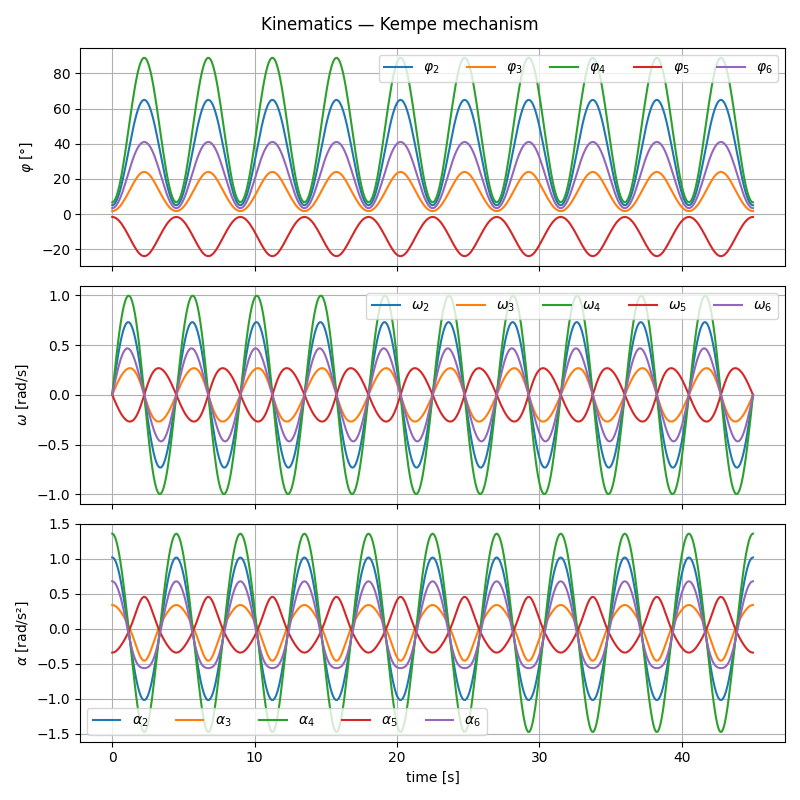

In [339]:
lengths = {link: length * scale for link, length in lengths.items()}
plt.close(fig)  # Close the figure to prevent it from displaying twice in Jupyter
#plots kinematics:
fig, axes = plt.subplots(3, 1, figsize=(8, 8), sharex=True)

# --- φ (angles) ---
axes[0].plot(t, np.degrees(phi2), label=r'$\varphi_2$')
axes[0].plot(t, np.degrees(phi3), label=r'$\varphi_3$')
axes[0].plot(t, np.degrees(phi4), label=r'$\varphi_4$')
axes[0].plot(t, np.degrees(phi5), label=r'$\varphi_5$')
axes[0].plot(t, np.degrees(phi6), label=r'$\varphi_6$')
axes[0].set_ylabel(r'$\varphi$ [°]')
axes[0].legend(ncol=5)
axes[0].grid()

# --- ω (angular velocities) ---
axes[1].plot(t, dphi2, label=r'$\omega_2$')
axes[1].plot(t, dphi3, label=r'$\omega_3$')
axes[1].plot(t, dphi4, label=r'$\omega_4$')
axes[1].plot(t, dphi5, label=r'$\omega_5$')
axes[1].plot(t, dphi6, label=r'$\omega_6$')
axes[1].set_ylabel(r'$\omega$ [rad/s]')
axes[1].legend(ncol=5)
axes[1].grid()

# --- α (angular accelerations) ---
axes[2].plot(t, ddphi2, label=r'$\alpha_2$')
axes[2].plot(t, ddphi3, label=r'$\alpha_3$')
axes[2].plot(t, ddphi4, label=r'$\alpha_4$')
axes[2].plot(t, ddphi5, label=r'$\alpha_5$')
axes[2].plot(t, ddphi6, label=r'$\alpha_6$')
axes[2].set_ylabel(r'$\alpha$ [rad/s²]')
axes[2].set_xlabel('time [s]')
axes[2].legend(ncol=5)
axes[2].grid()

plt.suptitle('Kinematics — Kempe mechanism')
plt.tight_layout()
plt.show()

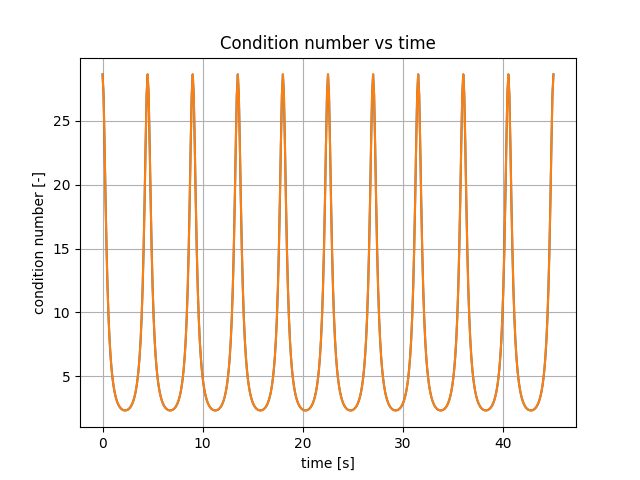

In [340]:
plt.close()
plt.figure()
plt.plot(t, cond)
plt.plot(t, cond2)
plt.xlabel('time [s]')
plt.ylabel('condition number [-]')
plt.title('Condition number vs time')
plt.grid(True)
plt.show()

<div style="width: 86ch;">

<h3>
</div>

<div style="width: 100%; overflow-x: auto; font-size: 0.85em;">
<a id="matrixmethode"></a>


\begin{equation*} 

 \begin{pmatrix}
 0 & 1 & 0 & 1 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\
 0 & 0 & 1 & 0 & 1 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\
 -1 & -L_{BH} \cdot c_{\phi1} & L_{BH} \cdot s_{\phi1} & -L_{FH} \cdot c_{\phi1} & L_{FH} \cdot s_{\phi1} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\
 0 & -1 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\
 0 & 0 & -1 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\
 0 & -1/2 \cdot L_{AB} \cdot c_{\phi2} & 1/2 \cdot L_{AB} \cdot s_{\phi2} & 0 & 0 & 0 & 0 & -1/2 \cdot L_{AB} \cdot c_{\phi2} & 1/2 \cdot L_{AB} \cdot s_{\phi2} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\
 0 & 0 & 0 & -1 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\
 0 & 0 & 0 & 0 & -1 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\
 0 & 0 & 0 & -1/2 \cdot L_{DF} \cdot c_{\phi4} & 1/2 \cdot L_{DF} \cdot s_{\phi4} & 0 & 0 & 0 & 0 & -1/2 \cdot L_{DF} \cdot c_{\phi4} & 1/2 \cdot L_{DF} \cdot s_{\phi4} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\
 0 & 0 & 0 & 0 & 0 & -1 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\
 0 & 0 & 0 & 0 & 0 & 0 & -1 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\
 1 & 0 & 0 & 0 & 0 & -1/2 \cdot L_{EH} \cdot c_{\phi6} & 1/2 \cdot L_{EH} \cdot s_{\phi6} & 0 & 0 & 0 & 0 & -1/2 \cdot L_{EH} \cdot c_{\phi6} & 1/2 \cdot L_{EH} \cdot s_{\phi6} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\
 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\
 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\
 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & -1/2 \cdot L_{AD} \cdot c_{\phi3} & 1/2 \cdot L_{AD} \cdot s_{\phi3} & 1/2 \cdot L_{AD} \cdot c_{\phi3} & -1/2 \cdot L_{AD} \cdot s_{\phi3} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\
 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\
 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\
 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & -1/2 \cdot L_{AE} \cdot c_{\phi3} & -1/2 \cdot L_{AE} \cdot s_{\phi3} & 1/2 \cdot L_{AE} \cdot c_{\phi3} & 1/2 \cdot L_{AE} \cdot s_{\phi3} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\
 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0\\
 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0\\
 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & -1/2 \cdot L_{AC} \cdot c_{\phi2} & -1/2 \cdot L_{AC} \cdot s_{\phi2} & 0 & 0 & 0 & 0 & 1/2 \cdot L_{AC} \cdot c_{\phi2} & 1/2 \cdot L_{AC} \cdot s_{\phi2} & 0 & 0 & 0 & 0\\
 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0\\
 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0\\
 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & -1/2 \cdot L_{EG} \cdot c_{\phi4} & -1/2 \cdot L_{EG} \cdot s_{\phi4} & 0 & 0 & 0 & 0 & 1/2 \cdot L_{EG} \cdot c_{\phi4} & 1/2 \cdot L_{EG} \cdot s_{\phi4} & 0 & 0\\
 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 1 & 0\\
 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 1\\
 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & -1/2 \cdot L_{DI} \cdot c_{\phi6} & -1/2 \cdot L_{DI} \cdot s_{\phi6} & 0 & 0 & 0 & 0 & 1/2 \cdot L_{DI} \cdot c_{\phi6} & 1/2 \cdot L_{DI} \cdot s_{\phi6}\\ 
 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\
 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\
 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\
 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0\\
 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\
 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0
 \end{pmatrix}

 \begin{pmatrix}
 M_{h}\\F_{g1x} \\ F_{g1y} \\ F_{g5x} \\ F_{g5y} \\ F_{g9x} \\ F_{g9y} \\ F_{1ax} \\ F_{1ay} \\ F_{5dx} \\ F_{5dy} \\ F_{9ex} \\ F_{9ey} \\ F_{3ax} \\ F_{3ay} \\ F_{3dx} \\ F_{3dy} \\ F_{4ax} \\ F_{4ay} \\ F_{4ex} \\ F_{4ey} \\ F_{2ax} \\ F_{2ay} \\ F_{6ex} \\ F_{6ey} \\ F_{8dx} \\ F_{8dy} \\ F_{27x} \\ F_{27y} \\ F_{67x} \\ F_{67y} \\ F_{87x} \\ F_{87y}
 \end{pmatrix}
 =
 \begin{pmatrix}
  0 \\ 0 \\ 0 \\ m_{AB} \cdot a_{ABx} \\ m_{AB} \cdot a_{ABy} \\ I_{AB} \cdot \alpha_{2} \\ m_{DF} \cdot a_{DFx} \\ m_{DF} \cdot a_{DFy} \\ I_{DF} \cdot \alpha_{4} \\ m_{EH} \cdot a_{EHx} \\ m_{EH} \cdot a_{EHy} \\ I_{EH} \cdot \alpha_{6} \\ m_{AD} \cdot a_{ADx} \\ m_{AD} \cdot a_{ADy} \\ I_{AD} \cdot \alpha_{3} \\ m_{AE} \cdot a_{AEx} \\ m_{AE} \cdot a_{AEy} \\ I_{AE} \cdot \alpha_{3} \\ m_{AC} \cdot a_{ACx} \\ m_{AC} \cdot a_{ACy}\\ I_{AC} \cdot \alpha_{2} \\m_{EG} \cdot a_{EGx} \\ m_{EG} \cdot a_{EGy} \\ I_{EG} \cdot \alpha_{4} \\ m_{DI} \cdot a_{DIx} \\ m_{DI} \cdot a_{DIy} \\ I_{DI} \cdot \alpha_{6} \\ 0 \\ 0 \\ 0 \\ 0 \\ 0 \\ 0
 \end{pmatrix}

\end{equation*}

letters zijn punten (buiten ground), getallen zijn stangen

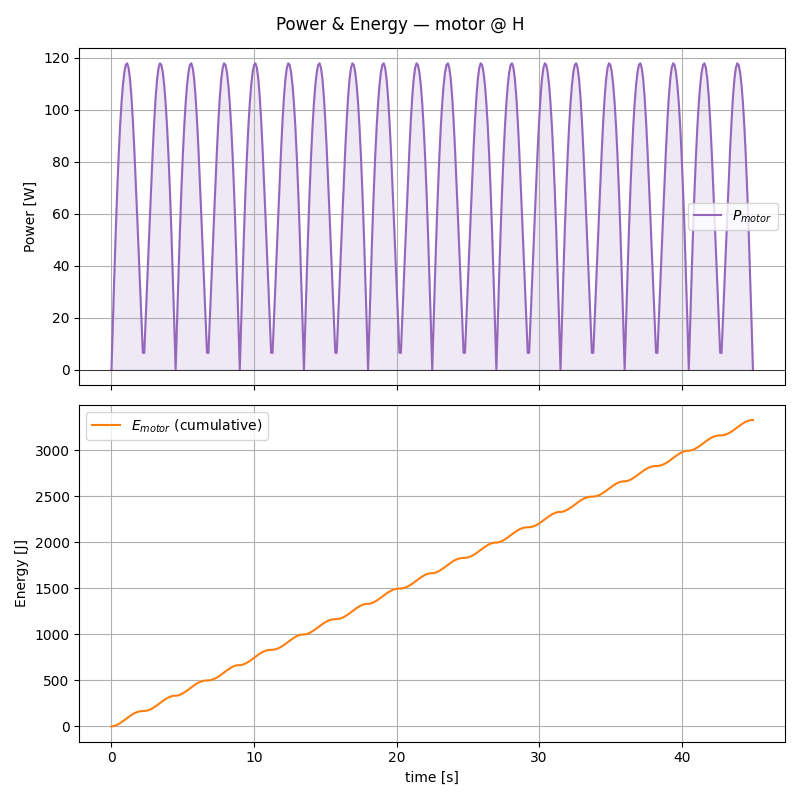

Total energy consumed: 3327.3960 J
Total energy in kWh: 0.000924 kWh
Total energy in kWh for 8 hours a day, 250 days a year: 147.884266 kWh


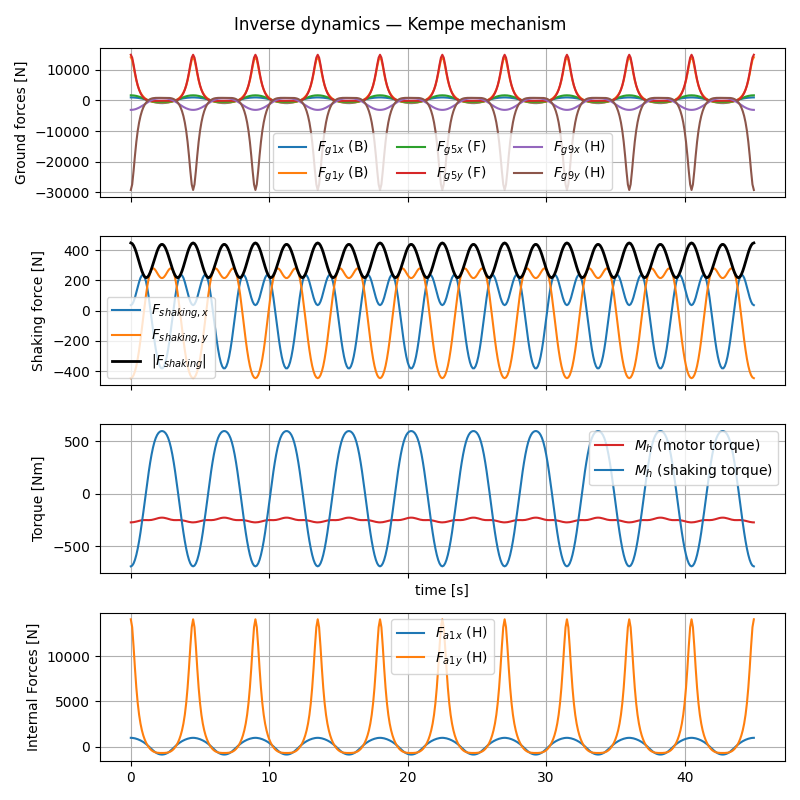

In [341]:
import numpy as np

# ── helpers ──────────────────────────────────────────────────────────────────

def _accel_cm(pivot_ax, pivot_ay, L, phi, dphi, ddphi):
    """Acceleration of the centre of mass of a link."""
    rx = 0.5 * L * np.cos(phi)
    ry = 0.5 * L * np.sin(phi)
    ax = pivot_ax - ddphi * ry - dphi**2 * rx
    ay = pivot_ay + ddphi * rx - dphi**2 * ry
    return ax, ay


def _point_accel(pivot_ax, pivot_ay, L, phi, dphi, ddphi):
    """Acceleration of the *end* of a link (full length from pivot)."""
    rx = L * np.cos(phi)
    ry = L * np.sin(phi)
    ax = pivot_ax - ddphi * ry - dphi**2 * rx
    ay = pivot_ay + ddphi * rx - dphi**2 * ry
    return ax, ay


# ── pivot accelerations ───────────────────────────────────────────────────────
# Ground pivots B and H have zero acceleration.

def compute_all_accelerations(lengths, phi2, phi3, phi4, phi5, phi6,
                               dphi2, dphi3, dphi4, dphi5, dphi6,
                               ddphi2, ddphi3, ddphi4, ddphi5, ddphi6,
                               phi1=0.0):
    """
    Compute all centre-of-mass accelerations needed for the b-vector.

    Parameters
    ----------
    lengths : dict with keys 'AB','AC','AD','AE','BH','BF','DF','EH','EG',
              'DI','CI','FH'
    phi2..6 : link angles at current time step [rad]
    dphi2..6: angular velocities               [rad/s]
    ddphi2..6: angular accelerations           [rad/s²]
    phi1    : ground angle (=0)

    Returns
    -------
    dict with keys  a_ABx, a_ABy, a_DFx, a_DFy, a_EHx, a_EHy,
                    a_ADx, a_ADy, a_AEx, a_AEy,
                    a_ACx, a_ACy, a_EGx, a_EGy, a_DIx, a_DIy
    """

    # ── Ground pivots (zero acceleration) ────────────────────────────────────
    Bax, Bay = 0.0, 0.0   # pivot B (fixed)
    Hax, Hay = 0.0, 0.0   # pivot H (fixed)
    Fax, Fay = 0.0, 0.0   # pivot F (fixed, phi1=0 → F=[0,−L_BF])

    # ── Link AB  (pivot B, angle φ2) ─────────────────────────────────────────
    a_ABx, a_ABy = _accel_cm(Bax, Bay,
                              lengths['AB'], phi2, dphi2, ddphi2)

    # ── Point A  (end of AB from B) ───────────────────────────────────────────
    Aax, Aay = _point_accel(Bax, Bay,
                             lengths['AB'], phi2, dphi2, ddphi2)

    # ── Link AC  (pivot A, angle φ2 – same crank) ────────────────────────────
    # AC hangs from A and rotates with the same angular kinematics as AB (φ2).
    a_ACx, a_ACy = _accel_cm(Aax, Aay,
                              lengths['AC'], phi2, dphi2, ddphi2)

    # ── Link AD  (pivot A, angle φ3) ─────────────────────────────────────────
    a_ADx, a_ADy = _accel_cm(Aax, Aay,
                              lengths['AD'], phi3, dphi3, ddphi3)

    # ── Point D  (end of AD from A) ───────────────────────────────────────────
    Dax, Day = _point_accel(Aax, Aay,
                             lengths['AD'], phi3, dphi3, ddphi3)

    # ── Link DF  (pivot F→D, angle φ4)
    # DF goes from fixed pivot F to D; CM is at midpoint.
    a_DFx, a_DFy = _accel_cm(Fax, Fay,
                              lengths['DF'], phi4, dphi4, ddphi4)

    # ── Link AE  (pivot A, angle φ5 – labelled phi3 in loop-2 closure) ───────
    # In the notebook phi5/dphi5/ddphi5 come from the second kinematics_4bar
    # call (loop BH–AB–AE–EH).
    a_AEx, a_AEy = _accel_cm(Aax, Aay,
                              lengths['AE'], phi5, dphi5, ddphi5)

    # ── Point E  (end of AE from A) ───────────────────────────────────────────
    Eax, Eay = _point_accel(Aax, Aay,
                             lengths['AE'], phi5, dphi5, ddphi5)

    # ── Link EH  (pivot H, angle φ6) ─────────────────────────────────────────
    a_EHx, a_EHy = _accel_cm(Hax, Hay,
                              lengths['EH'], phi6, dphi6, ddphi6)

    # ── Link EG  (pivot E, angle φ4 – EG rotates with the DF/EG coupler) ─────
    # EG shares the same angle as DF (φ4) in the Kempe linkage geometry.
    a_EGx, a_EGy = _accel_cm(Eax, Eay,
                              lengths['EG'], phi4, dphi4, ddphi4)

    # ── Link DI  (pivot D, angle φ6) ─────────────────────────────────────────
    # DI shares the same angle as EH (φ6).
    a_DIx, a_DIy = _accel_cm(Dax, Day,
                              lengths['DI'], phi6, dphi6, ddphi6)
    
    Cax, Cay = _point_accel(Aax, Aay,
                             lengths['AC'], phi2, dphi2, ddphi2)
    
    a_CIx, a_CIy = _accel_cm(Cax, Cay,
                              lengths['CI'], phi1, dphi=0.0, ddphi=0.0)

    return dict(
        a_ABx=a_ABx, a_ABy=a_ABy,
        a_DFx=a_DFx, a_DFy=a_DFy,
        a_EHx=a_EHx, a_EHy=a_EHy,
        a_ADx=a_ADx, a_ADy=a_ADy,
        a_AEx=a_AEx, a_AEy=a_AEy,
        a_ACx=a_ACx, a_ACy=a_ACy,
        a_EGx=a_EGx, a_EGy=a_EGy,
        a_DIx=a_DIx, a_DIy=a_DIy,
        a_CIx=a_CIx, a_CIy=a_CIy,
    )

motor_location = 'H'   # 'H', 'B', or 'F'
n_steps = len(t)
n_unknowns = 33

# Storage for all forces over time
forces = np.zeros((n_steps, n_unknowns))
F_shaking_x = np.zeros(n_steps)
F_shaking_y = np.zeros(n_steps)
M_shaking = np.zeros(n_steps)
for k in range(n_steps):
    # Extract scalar values at time step k
    p1 = phi1; p2  = phi2[k];   p3  = phi3[k];   p4  = phi4[k]
    p5  = phi5[k];   p6  = phi6[k]
    dp2 = dphi2[k];  dp3 = dphi3[k];  dp4 = dphi4[k]
    dp5 = dphi5[k];  dp6 = dphi6[k]
    ddp2 = ddphi2[k]; ddp3 = ddphi3[k]; ddp4 = ddphi4[k]
    ddp5 = ddphi5[k]; ddp6 = ddphi6[k]
    
    

    # Accelerations
    acc = compute_all_accelerations(
        lengths,
        p2, p3, p4, p5, p6,
        dp2, dp3, dp4, dp5, dp6,
        ddp2, ddp3, ddp4, ddp5, ddp6,
    )
    

    # ── Joint B: AB vs ground ────────────────────────────────────────────────
    # On AB:   +c*(dp2 - 0)    (ground pulls AB back)
    T_f_AB_at_B  =  c * dp2

    # ── Joint A: multiple links share this pin ───────────────────────────────
    # AB feels friction FROM each link that rotates relative to it at A:
    T_f_AB_at_A  =  c*(dp2-dp3) + c*(dp2-dp5) + c*(dp2-dp2)
    #                ↑ from AD    ↑ from AE     ↑ from AC (=0, same angle)

    # Net friction torque ON link AB:
    T_f_AB = T_f_AB_at_B + T_f_AB_at_A

    # ── Joint F: DF vs ground ────────────────────────────────────────────────
    T_f_DF_at_F  =  c * dp4

    # Joint D: DF feels friction from AD and DI
    T_f_DF_at_D  =  c*(dp4-dp3) + c*(dp4-dp6)
    #                ↑ from AD    ↑ from DI

    T_f_DF = T_f_DF_at_F + T_f_DF_at_D

    # ── Joint H: EH vs ground ────────────────────────────────────────────────
    T_f_EH_at_H  =  c * dp6

    # Joint E: EH feels friction from AE and EG
    T_f_EH_at_E  =  c*(dp6-dp5) + c*(dp6-dp4)
    #                ↑ from AE    ↑ from EG

    T_f_EH = T_f_EH_at_H + T_f_EH_at_E

    # ── Link AD: joints at A and D ───────────────────────────────────────────
    T_f_AD_at_A  =  c*(dp3-dp2)   # relative to AB
    T_f_AD_at_D  =  c*(dp3-dp4) + c*(dp3-dp6)
    #                ↑ vs DF       ↑ vs DI

    T_f_AD = T_f_AD_at_A + T_f_AD_at_D

    # ── Link AE: joints at A and E ───────────────────────────────────────────
    T_f_AE_at_A  =  c*(dp5-dp2)   # relative to AB
    T_f_AE_at_E  =  c*(dp5-dp6) + c*(dp5-dp4)
    #                ↑ vs EH       ↑ vs EG

    T_f_AE = T_f_AE_at_A + T_f_AE_at_E

    # ── Link AC: joints at A and C ───────────────────────────────────────────
    T_f_AC_at_A  =  0.0           # AC rotates with AB → no relative motion
    T_f_AC_at_C  =  c*(dp2-dp6)   # relative to CGI at C

    T_f_AC = T_f_AC_at_A + T_f_AC_at_C

    # ── Link EG: joints at E and G ───────────────────────────────────────────
    T_f_EG_at_E  =  c*(dp4-dp5)   # relative to AE
    T_f_EG_at_G  =  c*(dp4-dp6)   # relative to CGI at G

    T_f_EG = T_f_EG_at_E + T_f_EG_at_G

    # ── Link DI: joints at D and I ───────────────────────────────────────────
    T_f_DI_at_D  =  c*(dp6-dp3)   # relative to AD
    T_f_DI_at_I  =  0.0           # I is a free end (chisel contact, not a pin)

    T_f_DI = T_f_DI_at_D + T_f_DI_at_I

    # ── Link CGI: joints at C and G, free end at I ───────────────────────────
    T_f_CI_at_C =  c*(dp6-dp2)   # relative to AC at C
    T_f_CI_at_G =  c*(dp6-dp4)   # relative to EG at G

    T_f_CI = T_f_CI_at_C + T_f_CI_at_G


    A_k = np.array([
        # Link CI 
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, float(0.5*lengths['CI']), 0, float(0.5*lengths['CI']-lengths['CG']), 0, float(-0.5*lengths['CI']), 0],
        # Link: AB
        [0, -1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, -1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, float(-0.5*lengths['AB']*np.cos(p2)), float(0.5*lengths['AB']*np.sin(p2)), 0, 0, 0, 0, float(-0.5*lengths['AB']*np.cos(p2)), float(0.5*lengths['AB']*np.sin(p2)), 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        # Link: DF
        [0, 0, 0, -1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, -1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],    
        [0, 0, 0, float(-0.5*lengths['DF']*np.cos(p4)), float(0.5*lengths['DF']*np.sin(p4)), 0, 0, 0, 0, float(-0.5*lengths['DF']*np.cos(p4)), float(0.5*lengths['DF']*np.sin(p4)), 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        # Link: EH
        [0, 0, 0, 0, 0, -1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, -1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 0, 0, 0, 0, float(-0.5*lengths['EH']*np.cos(p6)), float(0.5*lengths['EH']*np.sin(p6)), 0, 0, 0, 0, float(-0.5*lengths['EH']*np.cos(p6)), float(0.5*lengths['EH']*np.sin(p6)), 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        # Link: AD
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, float(-0.5*lengths['AD']*np.cos(p3)), float(0.5*lengths['AD']*np.sin(p3)), float(0.5*lengths['AD']*np.cos(p3)), float(-0.5*lengths['AD']*np.sin(p3)), 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        # Link: AE
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, float(-0.5*lengths['AE']*np.cos(p3)), float(-0.5*lengths['AE']*np.sin(p3)), float(0.5*lengths['AE']*np.cos(p3)), float(0.5*lengths['AE']*np.sin(p3)), 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        # Link: AC
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, float(-0.5*lengths['AC']*np.cos(p2)), float(-0.5*lengths['AC']*np.sin(p2)), 0, 0, 0, 0, float(0.5*lengths['AC']*np.cos(p2)), float(0.5*lengths['AC']*np.sin(p2)), 0, 0, 0, 0],
        # Link: EG
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, float(-0.5*lengths['EG']*np.cos(p4)), float(-0.5*lengths['EG']*np.sin(p4)), 0, 0, 0, 0, float(0.5*lengths['EG']*np.cos(p4)), float(0.5*lengths['EG']*np.sin(p4)), 0, 0],
        # Link: DI
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, float(-0.5*lengths['DI']*np.cos(p6)), float(-0.5*lengths['DI']*np.sin(p6)), 0, 0, 0, 0, float(0.5*lengths['DI']*np.cos(p6)), float(0.5*lengths['DI']*np.sin(p6))],
        # Point: A
        [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        # Point: D
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
        # Point: E
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],], dtype=float)
    

    b_k = np.array([
        # rows 0-2: link 7 (CI)
        float(masses['CI'] * acc['a_CIx']-F_ext[k,0]), float(masses['CI'] * acc['a_CIy']-F_ext[k,1]), 0.0,
        # rows 3-5: link 1 (AB)
        float(masses['AB'] * acc['a_ABx']), float(masses['AB'] * acc['a_ABy']), float(I['AB'] * ddp2),
        # rows 6-8: link 5 (DF)
        float(masses['DF'] * acc['a_DFx']), float(masses['DF'] * acc['a_DFy']), float(I['DF'] * ddp4),
        # rows 9-11: link 9/10 (EH)
        float(masses['EH'] * acc['a_EHx']), float(masses['EH'] * acc['a_EHy']), float(I['EH'] * ddp6),
        # rows 12-14: link 3 (AD)
        float(masses['AD'] * acc['a_ADx']), float(masses['AD'] * acc['a_ADy']), float(I['AD'] * ddp3),
        # rows 15-17: link 4 (AE)
        float(masses['AE'] * acc['a_AEx']), float(masses['AE'] * acc['a_AEy']), float(I['AE'] * ddp5),
        # rows 18-20: link 2 (AC)
        float(masses['AC'] * acc['a_ACx']), float(masses['AC'] * acc['a_ACy']), float(I['AC'] * ddp2),
        # rows 21-23: link 6 (EG)
        float(masses['EG'] * acc['a_EGx']), float(masses['EG'] * acc['a_EGy']), float(I['EG'] * ddp4),
        # rows 24-26: link 8 (DI)
        float(masses['DI'] * acc['a_DIx']), float(masses['DI'] * acc['a_DIy']), float(I['DI'] * ddp6),
        # rows 27-28: node A
        0.0, 0.0,
        # rows 29-30: node D
        0.0, 0.0,
        # rows 31-32: node E
        0.0, 0.0,
    ], dtype=float)
    if gravity:
        # Add gravity forces to the b-vector (only vertical component)
        b_k[1] += masses['CI'] * g
        b_k[4] += masses['AB'] * g
        b_k[7] += masses['DF'] * g
        b_k[10] += masses['EH'] * g
        b_k[13] += masses['AD'] * g
        b_k[16] += masses['AE'] * g
        b_k[19] += masses['AC'] * g
        b_k[22] += masses['EG'] * g
        b_k[25] += masses['DI'] * g
    if friction:
        b_k[2] -= T_f_CI
        b_k[5] -= T_f_AB
        b_k[8] -= T_f_DF
        b_k[11] -= T_f_EH
        b_k[14] -= T_f_AD
        b_k[17] -= T_f_AE
        b_k[20] -= T_f_AC
        b_k[23] -= T_f_EG
        b_k[26] -= T_f_DI
    if spring: 
        T_spring = k_spring * (p6 - phi0_spring)
        b_k[11] -= T_spring  # spring torque on EH
    F_shaking_x[k] = -(masses['AB'] * acc['a_ABx'] + masses['AC'] * acc['a_ACx'] + masses['AD'] * acc['a_ADx'] + masses['AE'] * acc['a_AEx']+ masses['DF'] * acc['a_DFx'] + masses['EH'] * acc['a_EHx'] + masses['EG'] * acc['a_EGx'] + masses['DI'] * acc['a_DIx']+ masses['CI'] * acc['a_CIx'])
    F_shaking_y[k] = -(masses['AB'] * acc['a_ABy'] + masses['AC'] * acc['a_ACy'] + masses['AD'] * acc['a_ADy'] + masses['AE'] * acc['a_AEy']+ masses['DF'] * acc['a_DFy'] + masses['EH'] * acc['a_EHy'] + masses['EG'] * acc['a_EGy'] + masses['DI'] * acc['a_DIy']+ masses['CI'] * acc['a_CIy'])
    M_shaking[k] = -(I['AB'] * ddp2 + I['AC'] * ddp2 + I['AD'] * ddp3 + I['AE'] * ddp5 + I['DF'] * ddp4 + I['EH'] * ddp6 + I['EG'] * ddp4 + I['DI'] * ddp6 + I['CI'] * 0.0)

    


    forces[k] = np.linalg.solve(A_k, b_k)

# --- Extract named forces ---
M_motor     = forces[:, 0]  # motor torque at H


P_motor = M_motor * dphi6
# Energy (cumulative integral of |P_motor|)
E_motor = np.cumsum(np.abs(P_motor)) * (t[1] - t[0])

fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

axes[0].plot(t, abs(P_motor), color='tab:purple', label='$P_{motor}$')
axes[0].fill_between(t, abs(P_motor), 0, alpha=0.15, color='tab:purple')
axes[0].axhline(0, color='k', lw=0.5)
axes[0].set_ylabel('Power [W]'); axes[0].legend(); axes[0].grid()

axes[1].plot(t, E_motor, color='tab:orange', label='$E_{motor}$ (cumulative)')
axes[1].set_ylabel('Energy [J]'); axes[1].set_xlabel('time [s]')
axes[1].legend(); axes[1].grid()

plt.suptitle(f'Power & Energy — motor @ {motor_location}')
plt.tight_layout(); plt.show()

print(f"Total energy consumed: {E_motor[-1]:.4f} J")
print(f"Total energy in kWh: {E_motor[-1] / 3600000:.6f} kWh")
print(f"Total energy in kWh for 8 hours a day, 250 days a year: {(E_motor[-1] / 3600000)/45 *3600 * 8 * 250:.6f} kWh")

F_g1x   = forces[:, 1];  F_g1y = forces[:, 2]   # ground @ B
F_g5x   = forces[:, 3];  F_g5y = forces[:, 4]   # ground @ F
F_g9x   = forces[:, 5];  F_g9y = forces[:, 6]   # ground @ H
F_a1x   = forces[:, 7];  F_a1y = forces[:, 8]   # ground @ H


# --- Shaking forces (onbalans) ---
F_shaking   = np.sqrt(F_shaking_x**2 + F_shaking_y**2)

# --- Plot ---
fig, axes = plt.subplots(4, 1, figsize=(8, 8), sharex=True)

axes[0].plot(t, F_g1x, label='$F_{g1x}$ (B)'), axes[0].plot(t, F_g1y, label='$F_{g1y}$ (B)')
axes[0].plot(t, F_g5x, label='$F_{g5x}$ (F)'), axes[0].plot(t, F_g5y, label='$F_{g5y}$ (F)')
axes[0].plot(t, F_g9x, label='$F_{g9x}$ (H)'), axes[0].plot(t, F_g9y, label='$F_{g9y}$ (H)')
axes[0].set_ylabel('Ground forces [N]'); axes[0].legend(ncol=3); axes[0].grid()

axes[1].plot(t, F_shaking_x, label='$F_{shaking,x}$')
axes[1].plot(t, F_shaking_y, label='$F_{shaking,y}$')
axes[1].plot(t, F_shaking,   label='$|F_{shaking}|$', lw=2, color='k')
axes[1].set_ylabel('Shaking force [N]'); axes[1].legend(); axes[1].grid()

axes[2].plot(t, M_motor, color='tab:red', label='$M_h$ (motor torque)')
axes[2].plot(t, M_shaking, color='tab:blue', label='$M_h$ (shaking torque)')
axes[2].set_ylabel('Torque [Nm]'); axes[2].set_xlabel('time [s]')
axes[2].legend(); axes[2].grid()

axes[3].plot(t, F_a1x, label='$F_{a1x}$ (H)'), axes[3].plot(t, F_a1y, label='$F_{a1y}$ (H)')
axes[3].set_ylabel('Internal Forces [N]'); axes[3].legend(ncol=1); axes[3].grid()

plt.suptitle('Inverse dynamics — Kempe mechanism')
plt.tight_layout()
plt.show()



# Examen Vragen:
## Vraag 1
Waarvoor gebruikt de industrie het mechanisme of de nok? Hoe zou je het ontwerp aanpassen (geometrische parameers, positie van de motor, verandering van de timing in één cyclus,...) voor een andere toepassing?
Wordt gebruikt in preciesietoepassingen, aandrijving veranderen van een sinus naar een aangepast profiel voor processtappen.
    servo herprogrammeren,
    motor in H want laagste koppel,
    motor in B voor directere aandrijving,
    slag vergroten door aandere staafgrootte/ verhouding veranderen voor andere overbrengingshoek, 
    motion law aanpassen voor zachte aanraking,
    Zaag beweging,
    constante heen en weer beweging,
    harmonisch
Stansmachine: trapezium motion law, zeer stijve stangen (diepe press-hoeken), motor mogelijk op B voor snelle reactie bij fout.
Verpakkingsmachine: asymmetrisch profiel (snelle voeding, trage retour), hoge snelheid, servo-motor voor préciesopting.


## Vraag 2
Hoe optimiseer je het ontwerp  voor precisie? voor energieverbruik? voor krachtgeneratie?

    **Precisie**
    speling in gewrichten minimaliseren
    hoge stijfheid van de links: dik profiel en korte staven
    dode punten vermijden
    **Energieverbruik**
    opereren aan lagere snelheid --> lagere versnellingen --> lagere inertiekrachten
    licht materiaal voor lagere traagheid 
    motor op plaats met minimaal koppel
    torsieveer om energie op te slaan
    **Krachtengeneratie**
    Hoeken optimaliseren : bijna 90° hoek wanneer de grootste kracht moet worden geleverd
    grotere/stijvere staven: beperkte doorbuiging
    



## Vraag 3
Vliegwiel: welke afwegingen ("trade offs") heb je gemaakt, en waarom?
    vliegwiel dempt snelheidsvariaties, maar zorgt voor veel extra inertie en hogere kost.
    Geen vliegwiel wel torsieveer

    lagere precisie?

## Vraag 4
Keuze van bewegings-traject: welke afwegingen ("trade offs") heb je gemaakt, en waarom?

    Harmonische beweging beperkt jerk (schokken), maar weinig tijd aan het eindpunt ( geen probleem voor zagen)
    Bij snijden wel constante snelheid gewenst (zaag)
    Trapezium zorgt hiervoor maar hoge jerk en schokken
    lage piekkracht bij harmonisch ipv trapezium geschikt voor hoge snelheid




## Vraag 5
Hoe gebruik je de analyse van de frequentie-inhoud van je ontwerp? 



## Vraag 6 
Heeft je ontwerp dode punten ("singulariteiten")? Is dat erg?

    Ja er is een dood punt bij phi1 = 0(in B) en ja dat is erg want het systeem kan omklappen
    maar buiten het werkgebied
    numeriek onstabliel
    Oplossing motor in H of andere ratio van stangen zodat phi2 > 0
    beginhoek phi2 > 0


## Vraag 7 
Wat zijn de onbalans-eigenschappen van je ontwerp? Vormen die een probleem?
    Vormen een probleem wanneer ze groot zijn tov de snijkracht --> trillingen
    tegengewicht zou dit kunnen oplossen
    Twee mechanismes in tegenfase ook



## Vraag 8 
Wat zijn de relatieve invloeden van inertie, wrijving en stijfheid op je toepassing?

    **Inertie**
    dominant bij hogere snelheden, afweging tussen lage inertie en sterk genoeg mechanisme om doel uit te voeren
    afhankelijk van I en dus van m en L
    **Wrijving**
    Energieverlies in de scharnieren, domineert bij lage snelheden, klein maar meetbaar
    **Stijfheid**
    Hoe stijver, hoe meer het overeenkomt met het numeriek model
    Bij te lage stijfheid geen precisie meer
    Verwaarloosbaar en dus ook verwaarloosd


## Vraag 9
Hoe verandert je ontwerp als je verschillende kopies van je mechanisme in parallel laat aandrijven door dezelfde motor.
    
    In fase: liefst niet, cumulatieve krachten.
    Uit fase: Onbalans herstelt zichzelf (deels), krachten uitgespreid over beweging, zaag: dode punten
    Dubbel uitvoeren in tegengestelde zin heft onbalans perfect op bij beitel

## Vraag 10
Verander een parameter in je ontwerp, voorspel wat het effect zal zijn, en bereken de bijhorende numerieke analyse. 




We stellen  altijd de volgende bijvraag: hoeveel kost de motor voor je machine, en hoeveel kost het energieverbruik?

Energie: +-€0,16 per kWh
Motor servomotor (10 tot 150W): 300 tot 1000 euro nauwkeuriger dan stappenmotor 20 tot 100 euro
8u per dag 250 dagen per jaar 148kwh/jaar --> +-23.7 euro